# CIBUSmod example
This notebook privides an example of using CIBUSmod to run a number of scenarios that represent different combinations of demand and production-side "intervetions". For more thorough explanations see 'run_scn.ipynb'

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Run test scenario 'food-as-industry'

### Set up scenario and modules

Set path to folders containing all default and scenario data. Here we define a number of scenarios based on the same scenario Excel file but where we chose which madules and parameters are uppdated.

In [3]:
# Create session
session = cm.Session(
    name = 'MFF_measures',
    data_path = '../data',
    data_path_scenarios='../data/scenarios/MFF',
    data_path_output='../data/output/MFF'
)


# Define scenarios 
session.add_scenario(
    name = 'baseline',
    years = '2020'
)
session.add_scenario(
    name = 'FAI (demand)',                            # Name of scenario in outputs
    scenario_workbooks = 'food_as_industry',          # Name of scenario Excel file
    modules = ['Regions','DemandAndConversions'],     # Modules to update
    years = '2050'                                    # Years to calculate
)
session.add_scenario(
    name = 'FAI (+crop yields)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction'],
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+milk yield)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd'],
    pars = {
        'CattleHerd':['milk_prod'] # Only update 'milk_prod' parameter in CattleHerds
    },              
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+beef productivity)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight']
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+pork productivity)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight']
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+manure mgmt)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd','ManureMgmt'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight']
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+enteric methane)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd','ManureMgmt','FeedMgmt'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight'],
        'FeedMgmt' : 'enteric_adj'
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+electric field machinery)',
    scenario_workbooks = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd','ManureMgmt','FeedMgmt','MachineryAndEnergyMgmt'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight'],
        'FeedMgmt' : 'enteric_adj'
    },
    years = '2050'
)

A scenario with the name 'baseline' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (demand)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+crop yields)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+milk yield)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+beef productivity)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+pork productivity)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+manure mgmt)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+enteric methane)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI (+electric field machinery)' already exists use .up

Next, we initialise all model modules (python classes) that handle the calculations.

### Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]
runs

[('baseline', '2020'),
 ('FAI (demand)', '2050'),
 ('FAI (+crop yields)', '2050'),
 ('FAI (+milk yield)', '2050'),
 ('FAI (+beef productivity)', '2050'),
 ('FAI (+pork productivity)', '2050'),
 ('FAI (+manure mgmt)', '2050'),
 ('FAI (+enteric methane)', '2050'),
 ('FAI (+electric field machinery)', '2050')]

In [5]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

FAI (+crop yields), 2050 finished successfully in 6min 21s
FAI (+pork productivity), 2050 finished successfully in 6min 24s
baseline, 2020 finished successfully in 6min 37s
FAI (+manure mgmt), 2050 finished successfully in 6min 50s
FAI (+milk yield), 2050 finished successfully in 6min 50s
FAI (+beef productivity), 2050 finished successfully in 6min 55s
FAI (demand), 2050 finished successfully in 6min 53s
FAI (+enteric methane), 2050 finished successfully in 6min 57s
FAI (+electric field machinery), 2050 finished successfully in 3min 4s
CPU times: total: 62.5 ms
Wall time: 9min 35s


### Look at the data

In [6]:
session

,calculated
year,
2020,2025-01-21 15:19:03
,calculated
year,
2050,2025-01-21 15:19:19
,calculated
year,
2050,2025-01-21 15:18:44
,calculated
year,


## Plot output
Here are some example output plots.

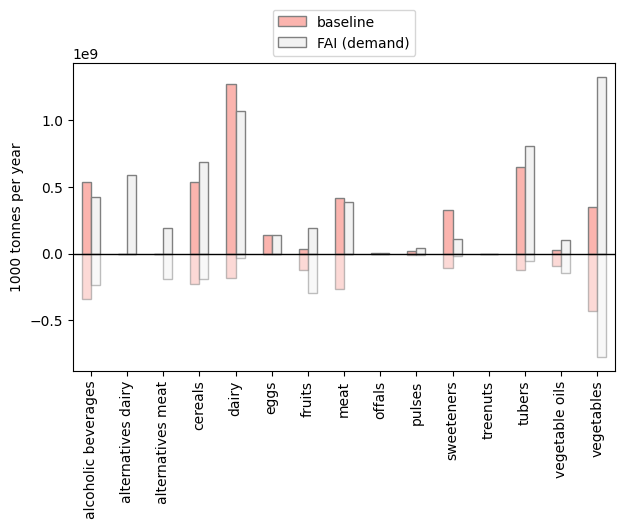

In [7]:
plot_data = (
    session.get_attr('D','food_demand_to_processing',['origin','food_group']).loc[['baseline','FAI (demand)']]
    .stack()
    .droplevel('year')
)
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

fig, ax = plt.subplots(figsize=(7,4))
plot_data['domestic'].unstack('scn').plot(kind='bar', cmap='Pastel1', edgecolor='grey', ax=ax)
(
    plot_data['imported'].unstack('scn')
    .rename({x:'_' for x in plot_data.index.get_level_values('scn').unique()}, axis=1)
).plot(kind='bar', cmap='Pastel1', edgecolor='grey', ax=ax, legend=False, alpha=0.5)

plt.hlines(0,-1,len(plot_data.index.unique('food_group')), color='black', linewidth=1)
ax.tick_params(axis='both', which='major')
ax.set_ylabel('1000 tonnes per year')
ax.set_xlabel('')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), fontsize=10)

plt.show()

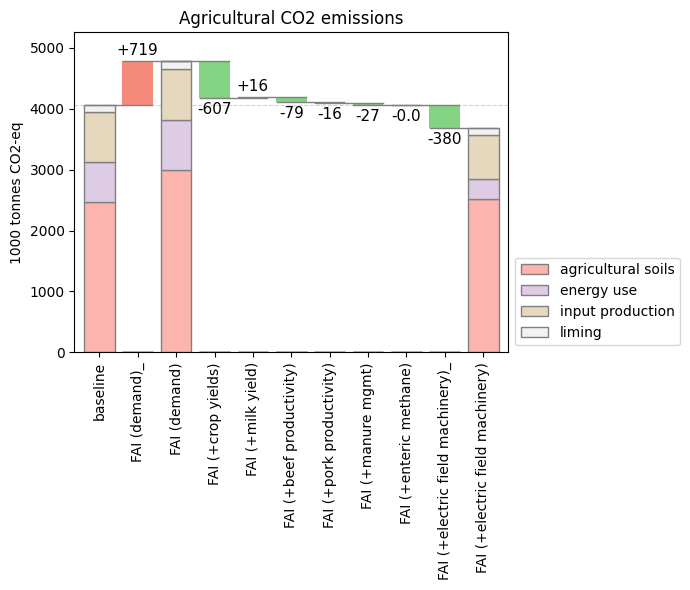

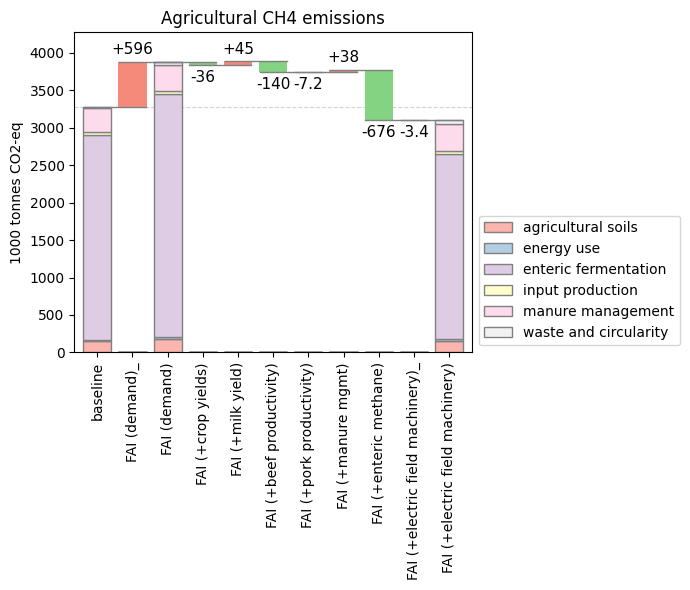

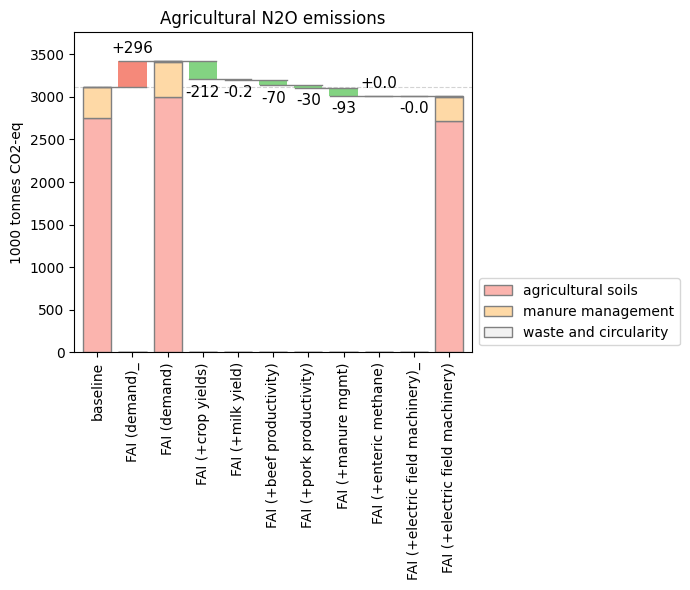

In [8]:
# CO2 ------------------------------------->
fig, ax = plt.subplots(figsize=(7,6))

plot_data1 = (
    cm.impact.get_GHG(session)
    .T.groupby(['compound','process']).sum().T
    .droplevel('year')
    .loc[:,['CO2']]
    .T.groupby('process').sum().T
)/1000000

plot.waterfall(
    data=plot_data1,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'], xmin=0, xmax=1, zorder=0, linestyle='--', linewidth=0.8, color='lightgrey')

ax.set_title('Agricultural CO2 emissions')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes CO2-eq')
ax.set_ylim(top=plot_data1.sum(axis=1).max()*1.1)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

# CH4 ------------------------------------->

fig, ax = plt.subplots(figsize=(7,6))

plot_data1 = (
    cm.impact.get_GHG(session)
    .T.groupby(['compound','process']).sum().T
    .droplevel('year')
    .loc[:,['CH4bio','CH4fos']]
    .T.groupby('process').sum().T
)/1000000

plot.waterfall(
    data=plot_data1,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'], xmin=0, xmax=1, zorder=0, linestyle='--', linewidth=0.8, color='lightgrey')

ax.set_title('Agricultural CH4 emissions')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes CO2-eq')
ax.set_ylim(top=plot_data1.sum(axis=1).max()*1.1)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

# N2O ------------------------------------->

fig, ax = plt.subplots(figsize=(7,6))

plot_data1 = (
    cm.impact.get_GHG(session)
    .T.groupby(['compound','process']).sum().T
    .droplevel('year')
    .loc[:,['N2O','N2Oind']]
    .T.groupby('process').sum().T
)/1000000

plot.waterfall(
    data=plot_data1,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'], xmin=0, xmax=1, zorder=0, linestyle='--', linewidth=0.8, color='lightgrey')

ax.set_title('Agricultural N2O emissions')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes CO2-eq')
ax.set_ylim(top=plot_data1.sum(axis=1).max()*1.1)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

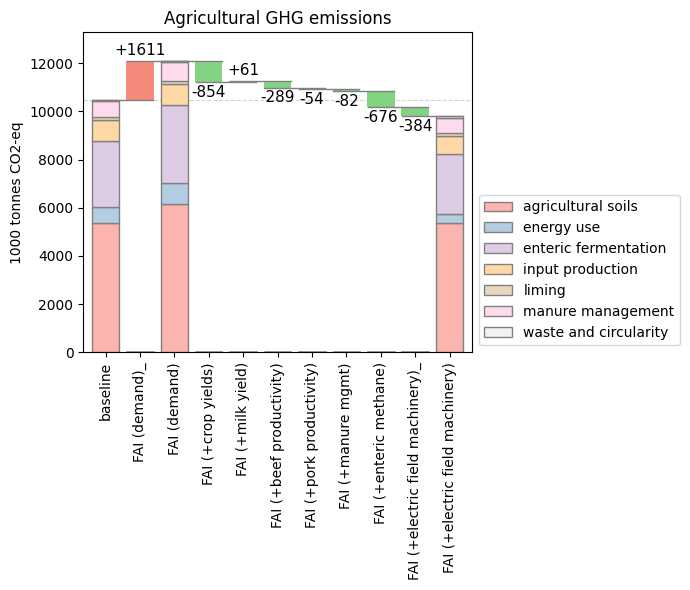

In [9]:
fig, ax = plt.subplots(figsize=(7,6))

plot_data1 = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
    .droplevel('year')
)/1000000

plot.waterfall(
    data=plot_data1,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'], xmin=0, xmax=1, zorder=0, linestyle='--', linewidth=0.8, color='lightgrey')

ax.set_title('Agricultural GHG emissions')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes CO2-eq')
ax.set_ylim(top=plot_data1.sum(axis=1).max()*1.1)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

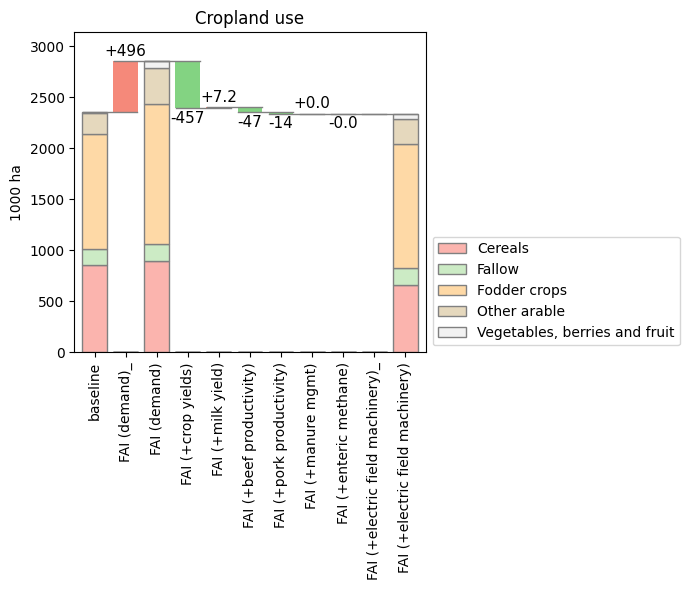

In [10]:
fig, ax = plt.subplots(figsize=(7,6))

plot_data2 = (
    (session.get_attr('C','area',groupby={'crop':'crop_group2'})/1000)
    .drop(['Greenhouse crops','Semi-natural grasslands'], axis=1)
    .droplevel('year')
)

plot.waterfall(
    data=plot_data2,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Cropland use')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 ha')
ax.set_ylim(top=plot_data2.sum(axis=1).max()*1.1)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

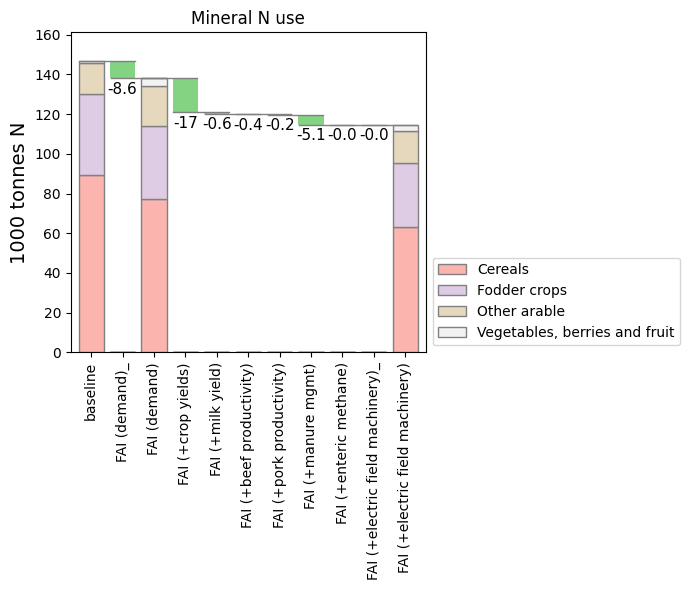

In [11]:
fig, ax = plt.subplots(figsize=(7,6))

plot_data3 = (
    (session.get_attr('C','fertiliser.mineral_N',groupby={'crop':'crop_group2'})/1000000)
    .drop(['Greenhouse crops','Semi-natural grasslands'], axis=1, errors='ignore')
    .droplevel('year')
)

plot.waterfall(
    data=plot_data3,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Mineral N use')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes N', size=14)
ax.set_ylim(top=plot_data3.sum(axis=1).max()*1.1)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

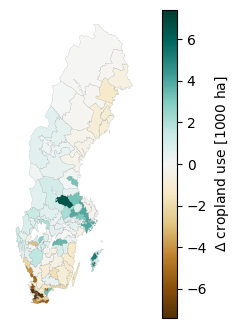

In [12]:
# CHANGES IN CROPLAND USE

plot_data = (
    session.get_attr('C','area',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1)
    /1000
)
plot_data = (plot_data - plot_data.loc[('baseline','2020')])

fig,ax = plt.subplots(figsize=(6,4))

map_data = plot_data.iloc[-1]
lim = abs(map_data).quantile(0.99)
plot.map_from_series(map_data, ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey', legend_kwds={'label': r'$\Delta$ cropland use [1000 ha]'})
ax.axis('off')

plt.show()

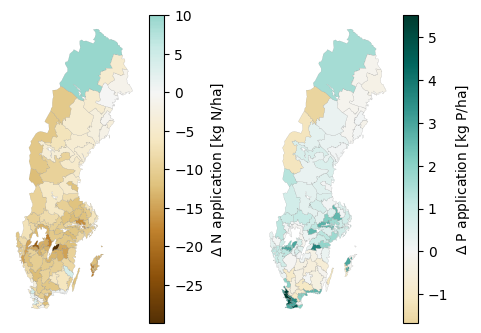

In [13]:
# CHANGES IN N AND P APPLICATION

plot_data_N = (
    (session.get_attr('C','fertiliser.manure_N',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1)
    + session.get_attr('C','fertiliser.mineral_N',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1))
    /
    session.get_attr('C','area',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1)
)
plot_data_N = (plot_data_N - plot_data_N.loc[('baseline','2020')])

plot_data_P = (
    (session.get_attr('C','fertiliser.manure_P',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1)
    + session.get_attr('C','fertiliser.mineral_P',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1))
    /
    session.get_attr('C','area',{'region':None,'crop':'land_use'}).xs('cropland', level='land_use', axis=1)
)
plot_data_P = (plot_data_P - plot_data_P.loc[('baseline','2020')])

fig,axs = plt.subplots(1,2, figsize=(6,4))

map_data = plot_data_N.iloc[-1]
ax=axs[0]
lim = abs(map_data).quantile(0.99)
plot.map_from_series(map_data, ax=ax, cmap='BrBG', cmap_zero_midpoint='shrink', edgecolor='grey', legend_kwds={'label': r'$\Delta$ N application [kg N/ha]'})
ax.axis('off')

map_data = plot_data_P.iloc[-1]
ax=axs[1]
lim = abs(map_data).quantile(0.99)
plot.map_from_series(map_data, ax=ax, cmap='BrBG', cmap_zero_midpoint='shrink',  edgecolor='grey', legend_kwds={'label': r'$\Delta$ P application [kg P/ha]'})
ax.axis('off')

plt.show()